In [14]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)# -> fungsi khusus yang menyimpan dataset MNIST 

x, y = mnist['data'], mnist['target'] # ->cara buat x dan y dalam satu baris.

y = y.astype(np.uint8) 



In [3]:
print(f'jumlah data x ; {x.shape[0]}')
print(f'jumlah data y ; {x.shape[1]}')

jumlah data x ; 70000
jumlah data y ; 784


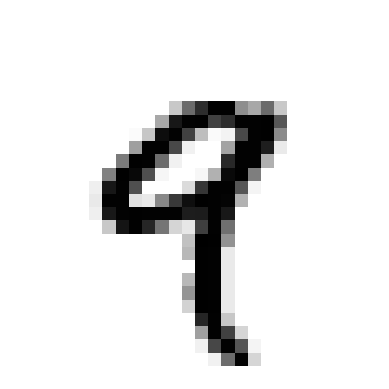

label angka : 9


In [4]:
def plot_digit(data):
    image = data.reshape(28,28)
    plt.imshow(image, cmap="binary")
    plt.axis('off')
    
plot_digit(x[4])
plt.show()
print(f'label angka : {y[4]}')

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x[:10000], y[:10000], test_size=0.2, random_state=42
) # -> x_train, y_train = latih model berdasarkan jawaban dari y_train. x_test soal ujian final, kunci jawabannya
  # -> ada di y_test

print(x_train.shape)
print(x_test.shape)

(8000, 784)
(2000, 784)


In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) # -> standar dicoding, variabel yang diskalakan di variabel baru
x_test_scaled = scaler.transform(x_test) # -> standar dicoding, variabel yang diskalakan di variabel baru

In [8]:
model_l2 = LinearSVC(penalty='l2', C=0.1, dual=True, max_iter=2000)
model_l2.fit(x_train_scaled,y_train )

model_l1 = LinearSVC(penalty='l1', C=0.1, dual=False, max_iter=2000)
model_l1.fit(x_train_scaled, y_train)

c:\Anaconda\envs\scit_ai\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,penalty,'l1'
,loss,'squared_hinge'
,dual,False
,tol,0.0001
,C,0.1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [9]:
pred_l2 = model_l2.predict(x_test_scaled)
pred_l1 = model_l1.predict(x_test_scaled)

print(f"Akurasi L2: {accuracy_score(y_test, pred_l2) * 100:.2f}%")
print(f"Akurasi L1: {accuracy_score(y_test, pred_l1) * 100:.2f}%")

Akurasi L2: 88.70%
Akurasi L1: 91.20%


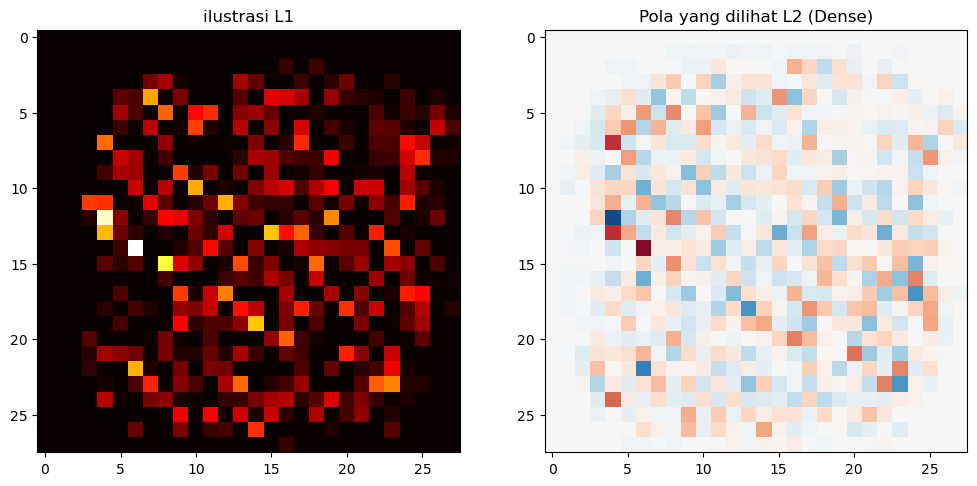

In [ ]:
coef_L1 = np.abs(model_l1.coef_[8].reshape(28,28))
coef_L2 = model_l2.coef_[8].reshape(28,28)

plt.figure(figsize=(12,10))

plt.subplot(1,2,1)
plt.imshow(coef_L1, cmap='hot')
plt.title("ilustrasi L1")

plt.subplot(1, 2, 2)
plt.imshow(coef_L2, cmap='RdBu', vmin=-0.5, vmax=0.5)
''' -> cmap = '''
plt.title("Pola yang dilihat L2 (Dense)")

plt.show()

In [16]:
hasil = classification_report(y_test, pred_l1)
print(hasil)

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       207
           1       0.92      0.97      0.95       216
           2       0.92      0.86      0.89       204
           3       0.84      0.89      0.86       192
           4       0.96      0.91      0.93       211
           5       0.88      0.84      0.86       176
           6       0.95      0.95      0.95       220
           7       0.92      0.94      0.93       216
           8       0.89      0.84      0.87       166
           9       0.89      0.89      0.89       192

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



In [20]:
hasil2 = classification_report(y_test,pred_l2)
print(hasil2)

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       207
           1       0.93      0.96      0.95       216
           2       0.88      0.82      0.85       204
           3       0.80      0.84      0.82       192
           4       0.96      0.89      0.92       211
           5       0.85      0.84      0.84       176
           6       0.94      0.92      0.93       220
           7       0.87      0.93      0.90       216
           8       0.84      0.80      0.82       166
           9       0.85      0.86      0.86       192

    accuracy                           0.89      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.89      0.89      0.89      2000

